# Topic: Analyzing the Dark Matter Halo Shape of M33 

### Question: How does the ellipticity of M33's DM halo shape change over time 

### Output Plots: Triaxiality versus time of M33's halo taken at R500, R500/2, and R500/4, DM particle density projections near time of M31-MW merger

In [2]:
# Nicolas Mazziotti

# import modules
import numpy as np
import astropy.units as u
from astropy.constants import G

# import plotting modules
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm

# my modules
from ReadFile import Read
from CenterOfMass import CenterOfMass
from MassProfile import MassProfile
from HaloShape import HaloShape

# for ellipse fitting 
from photutils.isophote import Ellipse, EllipseGeometry

In [5]:
for sma, i in np.array([300, 400, 500]):
    print(sma)
    print(i)

TypeError: cannot unpack non-iterable numpy.int64 object

In [2]:
# Directory on nimoy where the high resolution data files are stored
HighResDir = '../../../../astr400b/HighRes/'

# Create Projections At Every 10 Snapshots

In [3]:
# No lists; use arrays, or list comprehension

In [4]:
# Define snapshot range from 0 to 799, using every 10 snaps
snap_range = np.arange(0, 799, 10)

In [5]:
failed_snaps = [] # Sometimes the ellipse fitting fails, so store these snaps in this list
table_info = [] # Append rows of ellipse information to this list to create table from later on

axis1 = 0
axis2 = 1
# Looping through every 10 snapshots (tqdm to see progress)
for snap in [0]:
    # Create HaloShape object at given snap (see HaloShape.py)
    M33 = HaloShape('M33', snap)

    # See if ellipse fitting works for face-on projection of M33 
    try:
        # Retrieve fitting of all ellipses, and then the ellipticity, position angle, semimajor axis (a) in kpc, and semiminor axis (b)
        # in kpc at R500, R500/2, and R500/4
        isophotes, eps, pa, sma, smb = M33.PlotEllipses(axis1, axis2) # (0 means x axis, 1 means y axis)

        # Save the snapshot time (Myr), and the ellipse information at R500, R500/2, and R500/4 to a row for our table
        row = M33.time.value, *tuple(eps), *tuple(pa), *tuple(sma), *tuple(smb)

        # Append row to table
        table_info.append(row)

    # If the ellipse fitting fails it will raise a ValueError
    except ValueError:
        # Try again but with smaller initial semimajor axis guess of 5 pixels (default is 10 pixels)
        try:
            isophotes, eps, pa, sma, smb = M33.PlotEllipses(axis1, axis2, sma=5)
            row = M33.time.value, *tuple(eps), *tuple(pa), *tuple(sma), *tuple(smb)
            table_info.append(row)

        # If fails again, append snapshot to failed_snaps to see which snaps it failed at 
        except ValueError:  
            failed_snaps.append(snap)

In [2]:
M33 = HaloShape('M33', 0)

In [3]:
M33.PlotEllipses(0, 1)


(<photutils.isophote.isophote.IsophoteList at 0x7f0ab67b1b80>,
 array([0.11218774, 0.02308798, 0.12333993]),
 array([3.0636042 , 1.69817042, 0.91941678]),
 array([71.64613527, 36.76579595, 17.15151515]),
 array([67.50770387, 36.33889355, 16.05898547]))

In [13]:
failed_snaps

[130,
 200,
 210,
 230,
 280,
 340,
 390,
 400,
 430,
 460,
 470,
 480,
 490,
 500,
 510,
 520,
 530,
 540,
 550,
 560,
 570,
 590,
 600,
 610,
 620,
 630,
 640,
 650,
 670,
 680,
 690,
 700,
 710,
 720,
 730,
 740,
 750,
 760,
 770,
 780,
 790]

### Note: At each snapshot, the actual ellipses plotted on top of the projection are saved to the directory /plots/01/projections/. This is my other plot, which I will use later on to make a GIF. The radial profile of the fitted ellipses are similarly saved to /plots/01/ellipses/.

In [14]:
# Convert table information into a numpy array 
table_data = np.array(table_info)

# Save table to txt file 
np.savetxt(f'halo_evo_{axis1}{axis2}.txt', table_data, fmt = "%11.3f"*13, comments='#',
               header="{:>10s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}{:>11s}"\
                      .format('t', 'r500_eps', 'r500/2_eps', 'r500/4_eps', 
                              'r500_pa', 'r500/2_pa', 'r500/4_pa',
                             'r500_sma', 'r500/2_sma', 'r500/4_sma',
                             'r500_smb', 'r500/2_smb', 'r500/4_smb'))

In [15]:
# Read in table information for the face-on projection (denoted 01)
Halo_01 = np.genfromtxt('halo_evo_01.txt')
Halo_12 = np.genfromtxt('halo_evo_12.txt')
Halo_02 = np.genfromtxt('halo_evo_02.txt')

In [6]:
def Triaxiality(r500_index):
    """
    Function that computes the triaxiality parameter of M33 across time 

    INPUTS:
        -r500_index (int): An index of 1 computes the triaxiality at R500, 2 computes it at R500/2, and 3 computes it at R500/4

    OUTPUT:
        - time_range (numpy array of floats): Snapshot times where ellipse fitting succeeded (in Gyr) 
        - T (numpy array of floats): Triaxiality parameter 
    """
    # Read in table information for each projection
    Halo_01 = np.genfromtxt('halo_evo_01.txt')
    Halo_02 = np.genfromtxt('halo_evo_02.txt')
    Halo_12 = np.genfromtxt('halo_evo_12.txt')
 
    # Find the snapshots where ellipse fitting was successful across all three projections
    common = np.intersect1d(np.intersect1d(Halo_01[:,0], Halo_02[:,0]), Halo_12[:,0])

    # Mask the snapshots where not all three projections succeeded
    mask_01 = np.isin(Halo_01[:,0], common)
    mask_02 = np.isin(Halo_02[:,0], common)
    mask_12 = np.isin(Halo_12[:,0], common)

    # Calculate axis ratios from the ellipticity values 
    ar_01 = 1 - Halo_01[:, r500_index][mask_01]
    ar_02 = 1 - Halo_02[:, r500_index][mask_02]
    ar_12 = 1 - Halo_12[:, r500_index][mask_12]


    b_over_a = np.maximum(np.maximum(ar_01, ar_02), ar_12) # Uses projection with maximum axis ratio as b/a
    c_over_a = np.minimum(np.minimum(ar_01, ar_02), ar_12) # Uses projection with minimum axis ratio as c/a

    # Calculate triaxiality parameter 
    T = (1 - (b_over_a)**2)/(1 - (c_over_a)**2)

    # Convert time values from Myr to Gyr 
    time_range = Halo_01[:,0][mask_01]/1000
    
    return time_range, T

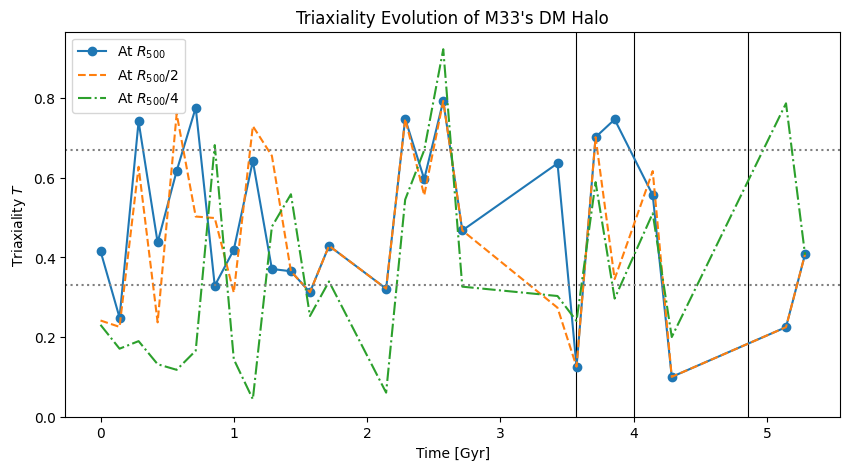

In [20]:
T_R500 = Triaxiality(1)
T_R500d2 = Triaxiality(2)
T_R500d4 = Triaxiality(3)

plt.figure(figsize=(10,5))

plt.axvline(3.57, c='k', linestyle='-', linewidth=0.8)
plt.axvline(4.0, c='k', linestyle='-', linewidth=0.8)
plt.axvline(4.86, c='k', linestyle='-', linewidth=0.8)

plt.plot(T_R500[0], T_R500[1], label=r'At $R_{500}$', marker='o')
plt.plot(T_R500d2[0], T_R500d2[1], linestyle='--', label=r'At $R_{500}/2$')
plt.plot(T_R500d4[0], T_R500d4[1], linestyle='-.', label=r'At $R_{500}/4$')

plt.axhline(0.33, c='gray', linestyle=':')
plt.axhline(0.67, c='gray', linestyle=':')

plt.legend()

plt.ylabel('Triaxiality $T$')
plt.xlabel('Time [Gyr]')

plt.title("Triaxiality Evolution of M33's DM Halo")

plt.savefig('Triaxiality_Evo.png', bbox_inches='tight')

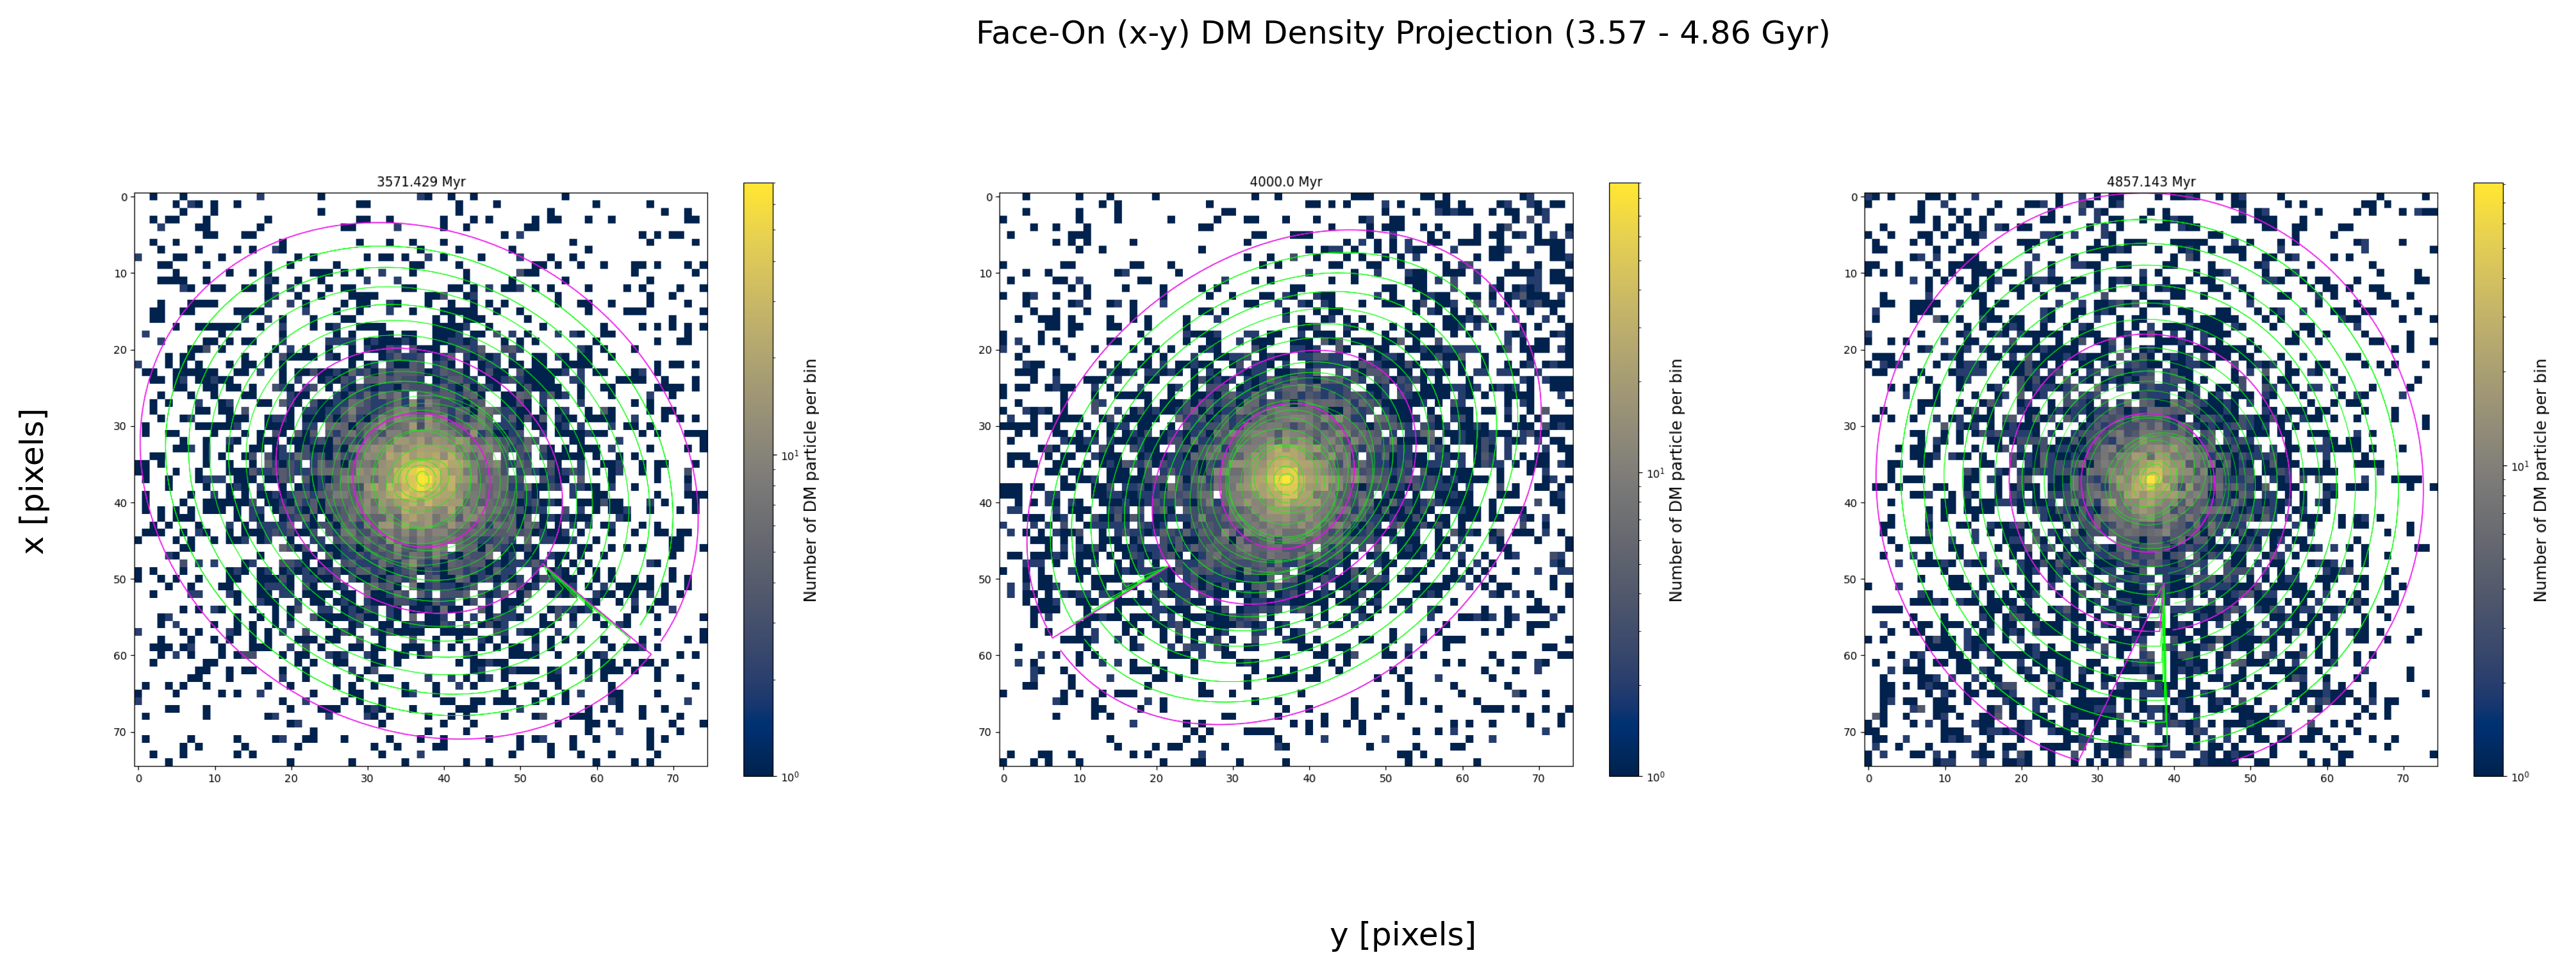

In [5]:
import matplotlib.image as mpimg

# Plot face-on projections near 4 Gyr (snapshot 280) to see changes due to merger
snap_280 = mpimg.imread('./plots/01/projections/M33_280.png')
snap_250 = mpimg.imread('./plots/01/projections/M33_250.png')
snap_340 = mpimg.imread('./plots/01/projections/M33_340.png')

fig, ax = plt.subplots(1, 3, figsize=(15,5), dpi=300)

ax[0].imshow(snap_250)
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

for spine in ax[0].spines.values():
    spine.set_visible(False)
    
ax[1].imshow(snap_280)
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

for spine in ax[1].spines.values():
    spine.set_visible(False)
    
ax[2].imshow(snap_340)
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

for spine in ax[2].spines.values():
    spine.set_visible(False)
    
fig.supxlabel('y [pixels]')
fig.supylabel('x [pixels]' )
fig.subplots_adjust(left=0.05, bottom=0.001, top=1)

fig.suptitle('Face-On (x-y) DM Density Projection (3.57 - 4.86 Gyr)')

fig.savefig('XY_Evo_NearMerger.pdf', bbox_inches='tight')